# CMI コンペティション 特徴量エンジニアリング検証

このノートブックでは、`preprocessing.py`の機能を使用して包括的な特徴量エンジニアリングを行います。

## 目次
1. ライブラリのインポート・データ読み込み
2. 基本統計量の計算
3. ピーク特徴量の計算
4. FFTバンドエネルギー計算
5. IMU世界座標系変換
6. 欠損センサーフラグ
7. TDA統計（Persistence Image）
8. AutoEncoder再構成誤差
9. Wavelet特徴量計算
10. 利き手反転正規化
11. 特徴量の統合・可視化
12. 結果の評価


## Step 1: ライブラリのインポート・データ読み込み


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
import yaml
warnings.filterwarnings('ignore')

# preprocessing.pyをインポート
sys.path.append('../src')
from utils.preprocessing import *

# 日本語フォント設定
plt.rcParams['font.family'] = 'DejaVu Sans'

print("ライブラリ読み込み完了")

# データファイルの読み込み
# 1) 設定読み込み
with open("../config/config_v2.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# ToFカラム自動展開
data_dir = cfg["data_dir"]
cache_dir = cfg["cache_dir"]
train_path = Path("../") / Path(data_dir) / "train.csv"
demographics_path = Path("../") / Path(data_dir) / "train_demographics.csv"
test_path = Path("../") / Path(data_dir) / "test.csv"
test_demographics_path = Path("../") / Path(data_dir) / "test_demographics.csv"

print(f"データパス確認:")
print(f"  train.csv: {train_path.exists()}")
print(f"  train_demographics.csv: {demographics_path.exists()}")
print(f"  test.csv: {test_path.exists()}")
print(f"  test_demographics.csv: {test_demographics_path.exists()}")

# データ読み込み
if train_path.exists():
    print(f"📂 データを読み込み中: {train_path}")
    train = pd.read_csv(train_path)
    print(f"✅ Train データ読み込み完了: {train.shape}")
else:
    print(f"❌ データファイルが見つかりません: {train_path}")
    raise FileNotFoundError(f"データファイルが見つかりません: {train_path}")

if demographics_path.exists():
    print(f"📂 人口統計データを読み込み中: {demographics_path}")
    demographics = pd.read_csv(demographics_path)
    print(f"✅ Demographics データ読み込み完了: {demographics.shape}")
else:
    print(f"❌ データファイルが見つかりません: {demographics_path}")
    raise FileNotFoundError(f"データファイルが見つかりません: {demographics_path}")

# データ結合
train_with_demographics = train.merge(demographics, on='subject', how='left')
print(f"✅ データ結合完了: {train_with_demographics.shape}")

# 基本情報表示
print("\n=== データ基本情報 ===")
print(f"訓練データサイズ: {train_with_demographics.shape}")
print(f"Demographics columns: {[col for col in train_with_demographics.columns]}")
print(f"ユニークな被験者数: {train_with_demographics['subject'].nunique()}")
print(f"ユニークなシークエンス数: {train_with_demographics['sequence_id'].nunique()}")
print(f"ユニークなジェスチャー数: {train_with_demographics['gesture'].nunique()}")
print(f"利き手分布:")
print(train_with_demographics['handedness'].value_counts())
print(train_with_demographics.head())


ライブラリ読み込み完了
データパス確認:
  train.csv: True
  train_demographics.csv: True
  test.csv: True
  test_demographics.csv: True
📂 データを読み込み中: ../data/train.csv
✅ Train データ読み込み完了: (574945, 341)
📂 人口統計データを読み込み中: ../data/train_demographics.csv
✅ Demographics データ読み込み完了: (81, 8)
✅ データ結合完了: (574945, 348)

=== データ基本情報 ===
訓練データサイズ: (574945, 348)
Demographics columns: ['row_id', 'sequence_type', 'sequence_id', 'sequence_counter', 'subject', 'orientation', 'behavior', 'phase', 'gesture', 'acc_x', 'acc_y', 'acc_z', 'rot_w', 'rot_x', 'rot_y', 'rot_z', 'thm_1', 'thm_2', 'thm_3', 'thm_4', 'thm_5', 'tof_1_v0', 'tof_1_v1', 'tof_1_v2', 'tof_1_v3', 'tof_1_v4', 'tof_1_v5', 'tof_1_v6', 'tof_1_v7', 'tof_1_v8', 'tof_1_v9', 'tof_1_v10', 'tof_1_v11', 'tof_1_v12', 'tof_1_v13', 'tof_1_v14', 'tof_1_v15', 'tof_1_v16', 'tof_1_v17', 'tof_1_v18', 'tof_1_v19', 'tof_1_v20', 'tof_1_v21', 'tof_1_v22', 'tof_1_v23', 'tof_1_v24', 'tof_1_v25', 'tof_1_v26', 'tof_1_v27', 'tof_1_v28', 'tof_1_v29', 'tof_1_v30', 'tof_1_v31', 'tof_1_v32', '

## Step 2: センサーカラムの特定とデータ前処理




| ステージ              | 具体的処理                                                                                     | 主なファイル／関数          |
| ----------------- | ----------------------------------------------------------------------------------------- | ------------------ |
| **① 入力データ**       | `train.csv`（332 センサ列＋メタ）<br>`train_demographics.csv`                                      | ―                  |
| **② 事前マスク**       | `clean_sensor_missing_values()`<br>‐ Accelerometer: 極端値→NaN<br>‐ ToF: 255↑＆-2↓→NaN（-1は保持） | `preprocessing.py` |
| **③ 利き手補正**       | `handedness_correction_v2()`（IMU左右反転）                                                     | 〃                  |
| **④ ToF 水平ミラー**   | 左利き行だけ `mirror_tof_rows()`                                                                | 〃                  |
| **⑤ 欠測補間**        | `clean_missing_sensor_data_parallel_disk()`<br>グループ単位（subject, sequence\_id）で並列処理         | `preprocessing.py` |
|   └ Accelerometer | 線形補間 (limit = 3 f)                                                                        |                    |
|   └ Rotation      | **SLERP** 補間 (limit = 120 f)                                                              |                    |
|   └ ToF\_Sensor   | −1→NaN→線形補間 (limit = 4 f)→残りNaNを-1復元                                                      |                    |
|   └ Thermal       | 線形補間 (limit = 120 f)                                                                      |                    |
| **⑥ 出力**          | 欠測を埋めた `train_final`（同じ列数）<br>キャッシュ: `cache/processed/train_final.parquet`                | ―                  |

### 重要パラメータ

```python
FPS          = 64          # 1 秒 ≒ 64 フレーム
interp_params = {
    "Accelerometer": {"method":"linear", "limit":3},
    "Rotation"     : {"method":"slerp" , "limit":120},
    "ToF_Sensor"   : {"method":"linear", "limit":4 , "fill_value":-1},
    "Thermal"      : {"method":"linear", "limit":120},
}
group_cols = ("subject", "sequence_id")
time_col   = "sequence_counter"
```



In [ ]:
# セル J-20: 一括で動作確認用 head() 表示
import re
import numpy as np
sys.path.append("../")
from src.utils.preprocessing import handedness_correction_v2, mirror_tof_rows, clean_sensor_missing_values, clean_missing_sensor_data_parallel_disk

# A) センサーカラムの定義
acc_cols = [c for c in train_with_demographics.columns if c.startswith("acc_")]
rot_cols = [c for c in train_with_demographics.columns if c.startswith("rot_")]
tof_cols = [c for c in train_with_demographics.columns if c.startswith("tof_")]
thm_cols = [c for c in train_with_demographics.columns if c.startswith("thm_")]
sensor_type_groups = {
    "Accelerometer": acc_cols,
    "Rotation":      rot_cols,
    "ToF_Sensor":    tof_cols,
    "Thermal":       thm_cols,
}

# B) 欠損マスク
train_masked = clean_sensor_missing_values(train_with_demographics, sensor_type_groups)

# C) IMU 利き手補正関数
train_hand = handedness_correction_v2(train_masked)

# D) ToF 水平ミラー関数
train_mirror = train_hand.copy()
left_mask = train_mirror["handedness"] == 0
train_mirror.loc[left_mask] = mirror_tof_rows(train_mirror.loc[left_mask], tof_cols)

# E) 時系列補間
interp_params = {
    "Accelerometer": {"limit": 3},
    "Rotation":      {"limit": 2},
    "ToF_Sensor":    {"method":"linear","limit":None,"fill_value":0},
    "Thermal":       {"limit": 5},
}

train_final = clean_missing_sensor_data_parallel_disk(
    train_mirror,
    sensor_type_groups=sensor_type_groups,
    interp_params=interp_params,
    group_cols=("subject","sequence_id"),
    time_col="sequence_counter",
    n_jobs=4,
    keep_tmp=False
)

# F) head() による動作確認
steps = {
    "原データ": train_with_demographics,
    "欠損マスク後": train_masked,
    "IMU利き手補正後": train_hand,
    "ToF水平ミラー後": train_mirror,
    "補間後": train_final
}

for name, df in steps.items():
    print(f"=== {name} head() ===")
    cols = ['sequence_id','sequence_counter','handedness','acc_y','acc_z','tof_1_v0','tof_1_v1']
    display(df.loc[:, cols].head())


interp:   0%|          | 0/8151 [00:00<?, ?seq/s]

concat:   0%|          | 0/8151 [00:00<?, ?it/s]

: 

In [2]:
import os
import sys
from pathlib import Path
import pandas as pd
import multiprocessing
import yaml
sys.path.append("../")
from src.utils.preprocessing import clean_sensor_missing_values, clean_missing_sensor_data_parallel_disk, handedness_correction_v2, mirror_tof_rows
from src.utils.imu import add_world_acc_features

print("=== キャッシュ対応パイプライン開始 ===")

# 1) 設定読み込み
with open("../config_v2.yaml", "r") as f:
    cfg = yaml.safe_load(f)
data_dir = cfg["data_dir"]
train_path = Path("../") / Path(data_dir) / "train.csv"
demographics_path = Path("../") / Path(data_dir) / "train_demographics.csv"

cfg_cache = cfg.get("cache_dir", "cache")
cache_dir = Path.cwd().parent / cfg_cache / "processed"
train_cache = cache_dir / "train_final.parquet"
print(f"キャッシュパス: {train_cache}")

# 2) 動的コア数取得
n_jobs = max(1, multiprocessing.cpu_count() - 1)
print(f"使用コア数: {n_jobs}")

# 3) キャッシュの有無をチェック
if train_cache.exists():
    print("✅ キャッシュ検出 → 読み込み中")
    train_final = pd.read_parquet(train_cache)
else:
    print("🛠 キャッシュ未検出 → 補間処理を実行")
    # A) カラム取得
    acc_cols = [c for c in train_with_demographics.columns if c.startswith("acc_")]
    rot_cols = [c for c in train_with_demographics.columns if c.startswith("rot_")]
    tof_cols = [c for c in train_with_demographics.columns if c.startswith("tof_")]
    thm_cols = [c for c in train_with_demographics.columns if c.startswith("thm_")]
    sensor_type_groups = {
        "Accelerometer": acc_cols,
        "Rotation":      rot_cols,
        "ToF_Sensor":    tof_cols,
        "Thermal":       thm_cols,
    }

    # B) 欠損マスク
    train_masked = clean_sensor_missing_values(train_with_demographics, sensor_type_groups)
    print(f"欠損マスク完了")

    # C) 利き手補正 + ToF ミラー
    train_hand = handedness_correction_v2(train_masked)
    left_idx   = train_hand["handedness"] == 0
    train_hand.loc[left_idx] = mirror_tof_rows(train_hand.loc[left_idx], tof_cols)
    print(f"補正完了")

    # D) 補間パラメータ
    # interp_params = {
    #     "Accelerometer": {"limit": 3},
    #     "Rotation":      {"limit": 2},
    #     "ToF_Sensor":    {"method":"linear","limit":None,"fill_value":0},
    #     "Thermal":       {"limit": 5},
    # }

    # E) 時系列補間
    train_final = clean_missing_sensor_data_parallel_disk(
        train_hand,
        sensor_type_groups=sensor_type_groups,
        # interp_params=interp_params,
        group_cols=("subject","sequence_id"),
        time_col="sequence_counter",
        n_jobs=n_jobs,
        keep_tmp=False
    )
    print(f"時系列補間完了")

    # F) キャッシュ保存
    cache_dir.mkdir(parents=True, exist_ok=True)
    train_final.to_parquet(train_cache, index=False)
    print(f"✅ 補間処理完了 & キャッシュ保存: {train_cache}")

    # F) head() による動作確認
    steps = {
        "原データ": train_with_demographics,
        "欠損マスク後": train_masked,
        "IMU利き手補正後": train_hand,
        "ToF水平ミラー後": train_mirror,
        "補間後": train_final
    }

    for name, df in steps.items():
        print(f"=== {name} head() ===")
        cols = ['sequence_id','sequence_counter','handedness','acc_y','acc_z','tof_1_v0','tof_1_v1']
        display(df.loc[:, cols].head())
        
# 4) 確認表示
print("\n=== 処理結果 ===")
print(f"データサイズ: {train_final.shape}")
display(train_final.loc[:, ['sequence_id','sequence_counter','handedness','acc_y','acc_z','tof_1_v0','tof_1_v1']].head())



=== キャッシュ対応パイプライン開始 ===


FileNotFoundError: [Errno 2] No such file or directory: '../config_v2.yaml'

In [10]:
from IPython.display import HTML, display
import pandas as pd

def show_steps_side_by_side(
    steps: dict[str, pd.DataFrame],
    cols: list[str],
    *,
    n_rows: int = 5,
    seq_id: str | None = None,
    query: str | None = None,
    na_color: str = "tomato",
):
    """
    steps  : {"ラベル": DataFrame, ...}
    cols   : 表示対象列
    n_rows : head の行数
    seq_id : 'sequence_id' でフィルタ（None なら全件）
    query  : pandas.DataFrame.query 互換の条件式
    """
    html_parts = []
    for name, df in steps.items():
        # --- 条件フィルタ -------------------------------------------
        _df = df
        if seq_id is not None:
            _df = _df[_df["sequence_id"] == seq_id]
        if query is not None:
            _df = _df.query(query, engine="python")
        # ------------------------------------------------------------

        sty = (
            _df.loc[:, cols]
               .head(n_rows)
               .style
               .set_caption(f"<b>{name}</b>")
               .format(precision=3, na_rep="NaN")
               .highlight_null(color=na_color)
               .set_table_attributes(
                   'class="dataframe" '
                   'style="display:inline-block; margin:0 1em 1em 0;"'
               )
        )
        html_parts.append(sty.to_html())

    display(HTML("".join(html_parts)))



# ------------------------------------------------------------

cols = ["sequence_id","sequence_counter","handedness",
        "acc_y","acc_z","tof_1_v0","tof_1_v1"]

steps = {
    "原データ":          train_with_demographics,
    "欠損マスク後":      train_masked,
    "IMU利き手補正後":   train_hand,
    "補間後":            train_final,
}

# 1) 行数だけ指定
# show_steps_side_by_side(steps, cols, n_rows=3)

# # 2) 特定 sequence_id だけ
# show_steps_side_by_side(steps, cols, seq_id="SEQ_000284", n_rows=7)

# 3) 任意の条件クエリ（例: ToF が -1 の行）
show_steps_side_by_side(steps, cols, query="handedness == 0", n_rows=10)

# # 4) sequence もクエリも併用
# show_steps_side_by_side(
#     steps, cols,
#     seq_id="SEQ_000284",
#     query="handedness == 1 & acc_y.abs() > 10",
#     n_rows=20,
#     na_color="gold"
# )



,sequence_id,sequence_counter,handedness,acc_y,acc_z,tof_1_v0,tof_1_v1
548,SEQ_000046,0,0,-2.055,1.711,215.000,205.000
549,SEQ_000046,1,0,-2.016,4.391,-1.000,-1.000
550,SEQ_000046,2,0,-2.016,4.086,-1.000,-1.000
551,SEQ_000046,3,0,-2.055,3.164,-1.000,220.000
552,SEQ_000046,4,0,-2.477,0.254,182.000,146.000
553,SEQ_000046,5,0,-3.242,-5.605,-1.000,-1.000
554,SEQ_000046,6,0,-1.367,-8.211,-1.000,-1.000
555,SEQ_000046,7,0,0.203,1.172,209.000,-1.000
556,SEQ_000046,8,0,-0.332,2.898,-1.000,-1.000
557,SEQ_000046,9,0,-3.320,4.125,-1.000,-1.000


In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
CMI ─ 前処理パイプライン（cache 対応 + world-frame 加速度）
"""

import os, sys, multiprocessing, yaml
from pathlib import Path
import pandas as pd
sys.path.append("../")

# ───────────────────────────────────────────────
# 0. path & util import
# ───────────────────────────────────────────────
sys.path.append("../")
from src.utils.preprocessing import (
    clean_sensor_missing_values,
    clean_missing_sensor_data_parallel_disk,
    handedness_correction_v2,
    mirror_tof_rows,
)
from src.utils.imu import add_world_acc_features

print("=== キャッシュ対応パイプライン開始 ===")

# ───────────────────────────────────────────────
# 1. 設定読み込み
# ───────────────────────────────────────────────
with open("../config/config_v2.yaml", "r") as f:
    cfg = yaml.safe_load(f)

with open("../config/interp_params.yaml", "r") as f:
    interp_params = yaml.safe_load(f)
    
data_dir   = Path("../") / cfg["data_dir"]
train_path = data_dir / "train.csv"
demo_path  = data_dir / "train_demographics.csv"

cache_root  = Path.cwd().parent / cfg.get("cache_dir", "cache") / "processed"
cache_root.mkdir(parents=True, exist_ok=True)
train_cache = cache_root / "train_final.parquet"
print(f"キャッシュパス: {train_cache}")

n_jobs = max(1, multiprocessing.cpu_count() // 2)
print(f"使用コア数: {n_jobs}")

# ───────────────────────────────────────────────
# 2. キャッシュ or 生データ読み込み
# ───────────────────────────────────────────────
if train_cache.exists():
    print("✅ キャッシュ検出 → 読み込み中")
    train_final = pd.read_parquet(train_cache)

else:
    print("🛠 キャッシュ未検出 → 前処理開始")

    # 2-1 原データ + demographics 結合
    train_raw = pd.read_csv(train_path)
    demographics = pd.read_csv(demo_path)
    train_with_demo = train_raw.merge(demographics, on="subject", how="left")

    # 2-2 欠損マスク
    acc_cols = [c for c in train_with_demo.columns if c.startswith("acc_")]
    rot_cols = [c for c in train_with_demo.columns if c.startswith("rot_")]
    tof_cols = [c for c in train_with_demo.columns if c.startswith("tof_")]
    thm_cols = [c for c in train_with_demo.columns if c.startswith("thm_")]
    sensor_type_groups = {
        "Accelerometer": acc_cols,
        "Rotation":      rot_cols,
        "ToF_Sensor":    tof_cols,
        "Thermal":       thm_cols,
    }

    train_masked = clean_sensor_missing_values(train_with_demo, sensor_type_groups)
    print("欠損マスク完了")

    # 2-3 欠損補間
    train_interp = clean_missing_sensor_data_parallel_disk(
        train_masked,
        sensor_type_groups=sensor_type_groups,
        interp_params=interp_params, 
        group_cols=("subject", "sequence_id"),
        time_col="sequence_counter",
        n_jobs=n_jobs,
        keep_tmp=False,
        keep_cols=list(demographics.columns),
    )
    print("時系列補間完了")

    # 2-4 利き手補正 + ToF 水平ミラー
    train_norm = handedness_correction_v2(train_interp)
    left_idx   = train_norm["handedness"] == 0
    train_mirror = train_norm.copy()
    train_mirror.loc[left_idx, tof_cols] = mirror_tof_rows(
        train_norm.loc[left_idx, :], tof_cols)
    print("利き手補正 + ToF ミラー完了")

    # 2-5 ワールド加速度 & 線形加速度  ★NEW
    train_final = add_world_acc_features(train_mirror)
    print("ワールド加速度列を追加")

    # 2-6 キャッシュ保存
    train_final.to_parquet(train_cache, index=False)
    print(f"✅ すべて完了 & キャッシュ保存: {train_cache}")

    # 2-7 動作確認 head
    debug_cols = [
        "sequence_id", "sequence_counter", "handedness",
        "acc_y", "acc_z",
        "acc_w_x", "acc_w_y", "acc_w_z",
        "lin_acc_x", "lin_acc_y", "lin_acc_z",
        "tof_1_v0", "tof_1_v1",
    ]
    display(train_final.loc[:, debug_cols].head())

# ───────────────────────────────────────────────
# 3. 結果概要
# ───────────────────────────────────────────────
print("\n=== 処理結果 ===")
print(f"Shape : {train_final.shape}")
print(f"Columns added: {[c for c in train_final.columns if c.startswith(('acc_w','lin_acc'))][:6]} ...")


=== キャッシュ対応パイプライン開始 ===
キャッシュパス: /mnt/c/Users/ShunK/works/CMI_comp/cache/processed/train_final.parquet
使用コア数: 6
🛠 キャッシュ未検出 → 前処理開始
欠損マスク完了


interp:   0%|          | 0/8151 [00:00<?, ?seq/s]

concat:   0%|          | 0/8151 [00:00<?, ?it/s]

時系列補間完了
利き手補正 + ToF ミラー完了
ワールド加速度列を追加
✅ すべて完了 & キャッシュ保存: /mnt/c/Users/ShunK/works/CMI_comp/cache/processed/train_final.parquet


,sequence_id,sequence_counter,handedness,acc_y,acc_z,acc_w_x,acc_w_y,acc_w_z,lin_acc_x,lin_acc_y,lin_acc_z,tof_1_v0,tof_1_v1
0,SEQ_000284,0,1,-1.476562,-11.394531,-3.035093,-4.273569,11.574952,-3.035093,-4.273569,1.768302,-1.0,-1.0
1,SEQ_000284,1,1,1.894531,-9.281250,-5.424473,-7.690712,5.796160,-5.424473,-7.690712,-4.010490,-1.0,-1.0
2,SEQ_000284,2,1,2.699219,-3.230469,-3.380318,-1.650433,3.291799,-3.380318,-1.650433,-6.514851,-1.0,-1.0
3,SEQ_000284,3,1,2.390625,5.542969,0.669669,-0.074434,12.204886,0.669669,-0.074434,2.398236,-1.0,-1.0
4,SEQ_000284,4,1,1.816406,4.238281,0.084353,0.746297,11.694667,0.084353,0.746297,1.888017,-1.0,-1.0



=== 処理結果 ===
Shape : (574945, 348)
Columns added: ['acc_w_x', 'acc_w_y', 'acc_w_z', 'lin_acc_x', 'lin_acc_y', 'lin_acc_z'] ...


In [10]:
from IPython.display import HTML, display
import pandas as pd

def show_steps_side_by_side(
    steps: dict[str, pd.DataFrame],
    cols: list[str],
    *,
    n_rows: int = 5,
    seq_id: str | None = None,
    query: str | None = None,
    na_color: str = "tomato",
):
    """
    steps  : {"ラベル": DataFrame, ...}
    cols   : 表示対象列
    n_rows : head の行数
    seq_id : 'sequence_id' でフィルタ（None なら全件）
    query  : pandas.DataFrame.query 互換の条件式
    """
    html_parts = []
    for name, df in steps.items():
        # --- 条件フィルタ -------------------------------------------
        _df = df
        if seq_id is not None:
            _df = _df[_df["sequence_id"] == seq_id]
        if query is not None:
            _df = _df.query(query, engine="python")
        # ------------------------------------------------------------

        sty = (
            _df.loc[:, cols]
               .head(n_rows)
               .style
               .set_caption(f"<b>{name}</b>")
               .format(precision=3, na_rep="NaN")
               .highlight_null(color=na_color)
               .set_table_attributes(
                   'class="dataframe" '
                   'style="display:inline-block; margin:0 1em 1em 0;"'
               )
        )
        html_parts.append(sty.to_html())

    display(HTML("".join(html_parts)))



# ------------------------------------------------------------

cols = ["sequence_id","sequence_counter","handedness",
        "acc_y","acc_z","tof_1_v0","tof_1_v1"]

steps = {
    "原データ":          train_with_demographics,
    "欠損マスク後":      train_masked,
    "IMU利き手補正後":   train_mirror,
    "補間後":            train_final,
}

# 1) 行数だけ指定
# show_steps_side_by_side(steps, cols, n_rows=3)

# # 2) 特定 sequence_id だけ
show_steps_side_by_side(steps, cols, seq_id="SEQ_000046", n_rows=7)

# 3) 任意の条件クエリ（例: ToF が -1 の行）
show_steps_side_by_side(steps, cols, query="handedness == 0", n_rows=10)

# # 4) sequence もクエリも併用
# show_steps_side_by_side(
#     steps, cols,
#     seq_id="SEQ_000284",
#     query="handedness == 1 & acc_y.abs() > 10",
#     n_rows=20,
#     na_color="gold"
# )



,sequence_id,sequence_counter,handedness,acc_y,acc_z,tof_1_v0,tof_1_v1
548,SEQ_000046,0,0,-2.055,1.711,215.000,205.000
549,SEQ_000046,1,0,-2.016,4.391,-1.000,-1.000
550,SEQ_000046,2,0,-2.016,4.086,-1.000,-1.000
551,SEQ_000046,3,0,-2.055,3.164,-1.000,220.000
552,SEQ_000046,4,0,-2.477,0.254,182.000,146.000
553,SEQ_000046,5,0,-3.242,-5.605,-1.000,-1.000
554,SEQ_000046,6,0,-1.367,-8.211,-1.000,-1.000
,sequence_id,sequence_counter,handedness,acc_y,acc_z,tof_1_v0,tof_1_v1
548,SEQ_000046,0,0,-2.055,1.711,215.000,205.000
549,SEQ_000046,1,0,-2.016,4.391,-1.000,-1.000


,sequence_id,sequence_counter,handedness,acc_y,acc_z,tof_1_v0,tof_1_v1
548,SEQ_000046,0,0,-2.055,1.711,215.000,205.000
549,SEQ_000046,1,0,-2.016,4.391,-1.000,-1.000
550,SEQ_000046,2,0,-2.016,4.086,-1.000,-1.000
551,SEQ_000046,3,0,-2.055,3.164,-1.000,220.000
552,SEQ_000046,4,0,-2.477,0.254,182.000,146.000
553,SEQ_000046,5,0,-3.242,-5.605,-1.000,-1.000
554,SEQ_000046,6,0,-1.367,-8.211,-1.000,-1.000
555,SEQ_000046,7,0,0.203,1.172,209.000,-1.000
556,SEQ_000046,8,0,-0.332,2.898,-1.000,-1.000
557,SEQ_000046,9,0,-3.320,4.125,-1.000,-1.000


In [5]:
# === quick_sensor_report ====================================
import numpy as np, pandas as pd
from IPython.display import display

def quick_sensor_report(df: pd.DataFrame) -> pd.DataFrame:
    """各センサ prefix ごとの min / max / NaN 率 / 四元数ノルム逸脱を集計"""
    report = []
    for pre in ("acc", "rot", "acc_w", "lin_acc", "tof", "thm"):
        cols = [c for c in df.columns if c.startswith(pre)]
        if not cols:
            continue
        arr = df[cols].to_numpy()
        nan_ratio = np.isnan(arr).mean()
        min_v, max_v = np.nanmin(arr), np.nanmax(arr)
        norm_err = np.nan
        if pre == "rot":
            q = arr.reshape(-1, 4)
            norm_err = np.abs(np.linalg.norm(q, axis=1) - 1).max()
        report.append(dict(sensor=pre, min=min_v, max=max_v,
                           nan_ratio=f"{nan_ratio:.3%}",
                           norm_error=f"{norm_err:.3e}"))

    rep = pd.DataFrame(report).set_index("sensor").sort_index()
    return rep

display(quick_sensor_report(train_final))


,min,max,nan_ratio,norm_error
sensor,,,,
acc,-34.585938,38.328125,0.000%,nan
acc_w,-30.127451,34.692646,0.000%,nan
lin_acc,-38.972295,33.290070,0.000%,nan
rot,-0.999871,1.000000,0.000%,2.220e-16
thm,-0.370413,39.588390,2.106%,nan
tof,-1.000000,249.000000,0.000%,nan


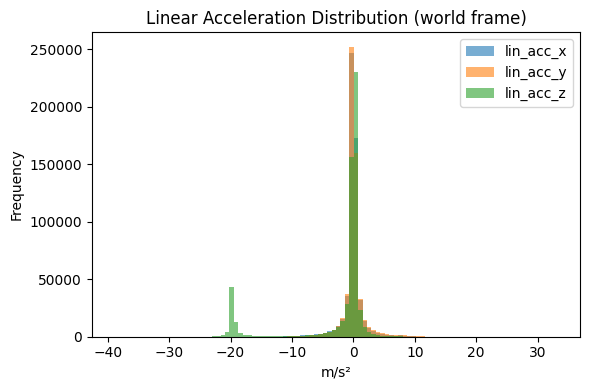

In [6]:
# === lin_acc distribution ===================================
import matplotlib.pyplot as plt
import numpy as np

ax = train_final[["lin_acc_x","lin_acc_y","lin_acc_z"]].plot(
    kind="hist", bins=100, alpha=0.6, figsize=(6,4), sharex=True)
ax.set_title("Linear Acceleration Distribution (world frame)")
ax.set_xlabel("m/s²"); plt.tight_layout()
plt.show()


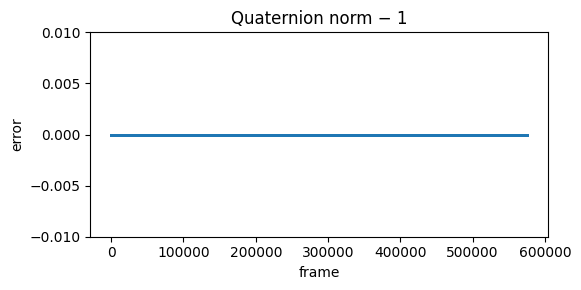

In [7]:
# === quaternion norm scatter =================================
import matplotlib.pyplot as plt
import numpy as np

q = train_final[["rot_w","rot_x","rot_y","rot_z"]].to_numpy()
norm_err = np.linalg.norm(q, axis=1) - 1
plt.figure(figsize=(6,3))
plt.scatter(range(len(norm_err)), norm_err, s=1)
plt.title("Quaternion norm − 1"); plt.ylabel("error"); plt.xlabel("frame")
plt.ylim(-1e-2, 1e-2); plt.tight_layout(); plt.show()


TypeError: Image data of dtype object cannot be converted to float

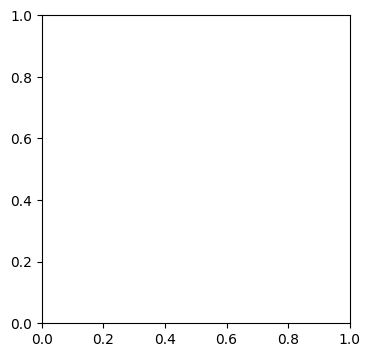

In [8]:
# === ToF heatmap (sensor 1) =================================
import matplotlib.pyplot as plt
import numpy as np

def plot_tof_heatmap(df: pd.DataFrame, seq_id: str, frame: int = 0, sensor: int = 1):
    row = df[(df.sequence_id == seq_id) & (df.sequence_counter == frame)].iloc[0]
    vals = row[[f"tof_{sensor}_v{i}" for i in range(64)]].to_numpy().reshape(8,8)
    plt.figure(figsize=(4,4))
    plt.imshow(vals, cmap="viridis", origin="lower")
    plt.colorbar(label="distance (mm)")
    plt.title(f"ToF sensor {sensor} – {seq_id} frame {frame}")
    plt.axis("off"); plt.show()

plot_tof_heatmap(train_final, seq_id="SEQ_000046", frame=0)


## Step 3: スライディングウィンドウの作成


In [ ]:
print("=== スライディングウィンドウの作成 ===")

import yaml
import numpy as np
import pandas as pd
sys.path.append('../')
from src.utils.preprocessing import create_sliding_windows_with_demographics, normalize_sensor_data, normalize_tabular_data

# 1) 設定読み込み
with open("../config_v2.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# ToFカラム自動展開
acc_cols = cfg["sensor_acc_cols"]
rot_cols = cfg["sensor_rot_cols"]
tof_cols = [f"tof_{d}_v{i}" for d in range(1, 6) for i in range(64)]
thm_cols = cfg["sensor_thm_cols"]
sensor_cols = acc_cols + rot_cols + tof_cols + thm_cols
window_size      = cfg["preprocessing"]["window_size"]
stride      = cfg["preprocessing"]["stride"]
min_len = cfg["preprocessing"]["min_sequence_length"]
pv      = cfg["preprocessing"]["padding_value"]
demographics_cols = cfg["demographics_cols"]

# 全センサーカラム
# train_demographics = pd.read_csv(demographics_path)
# train_demographics.drop(columns=['handedness'], inplace=True)
# df = train_data_cleaned.merge(train_demographics, on='subject', how='left')
print(train_final.columns.tolist())
print(sensor_cols)
print(demographics_cols)

# スライディングウィンドウの作成
X_sensor_windows, X_demographics_windows, y_windows, window_info = create_sliding_windows_with_demographics(
    train_final,
    window_size=window_size,
    stride=stride,
    sensor_cols=sensor_cols,
    demographics_cols=demographics_cols,
    min_sequence_length=min_len,
    padding_value=pv,
)

print(f"センサーウィンドウ: {X_sensor_windows.shape}")
print(f"人口統計ウィンドウ: {X_demographics_windows.shape}")
print(f"ラベルウィンドウ: {y_windows.shape}")
print(f"ウィンドウ情報: {len(window_info)}")

# ウィンドウ情報の確認
print("\n=== ウィンドウ情報の確認 ===")
print(f"ウィンドウ数: {len(window_info)}")
print(f"最初のウィンドウ情報: {window_info[0]}")

# ジェスチャー別のウィンドウ数
unique_gestures, counts = np.unique(y_windows, return_counts=True)
print(f"\nジェスチャー別のウィンドウ数:")
for gesture, count in zip(unique_gestures, counts):
    print(f"  {gesture}: {count}")

# データの正規化
print("\n=== データの正規化 ===")
X_sensor_normalized, sensor_scaler = normalize_sensor_data(X_sensor_windows)
X_demographics_normalized, demo_scaler = normalize_tabular_data(X_demographics_windows)

print(f"正規化後のセンサーデータ: {X_sensor_normalized.shape}")
print(f"正規化後の人口統計データ: {X_demographics_normalized.shape}")
print(f"センサーデータの統計: mean={X_sensor_normalized.mean():.4f}, std={X_sensor_normalized.std():.4f}")
print(f"人口統計データの統計: mean={X_demographics_normalized.mean():.4f}, std={X_demographics_normalized.std():.4f}")

# 結果の保存
print("\n=== データの保存 ===")
window_data = {
    'X_sensor_windows': X_sensor_windows,
    'X_sensor_normalized': X_sensor_normalized,
    'X_demographics_windows': X_demographics_windows,
    'X_demographics_normalized': X_demographics_normalized,
    'y_windows': y_windows,
    'window_info': window_info,
    'sensor_scaler': sensor_scaler,
    'demo_scaler': demo_scaler
}

print(f"ウィンドウデータを変数に保存しました。")


=== スライディングウィンドウの作成 ===
['row_id', 'sequence_type', 'sequence_id', 'sequence_counter', 'subject', 'orientation', 'behavior', 'phase', 'gesture', 'acc_x', 'acc_y', 'acc_z', 'rot_w', 'rot_x', 'rot_y', 'rot_z', 'thm_1', 'thm_2', 'thm_3', 'thm_4', 'thm_5', 'tof_1_v0', 'tof_1_v1', 'tof_1_v2', 'tof_1_v3', 'tof_1_v4', 'tof_1_v5', 'tof_1_v6', 'tof_1_v7', 'tof_1_v8', 'tof_1_v9', 'tof_1_v10', 'tof_1_v11', 'tof_1_v12', 'tof_1_v13', 'tof_1_v14', 'tof_1_v15', 'tof_1_v16', 'tof_1_v17', 'tof_1_v18', 'tof_1_v19', 'tof_1_v20', 'tof_1_v21', 'tof_1_v22', 'tof_1_v23', 'tof_1_v24', 'tof_1_v25', 'tof_1_v26', 'tof_1_v27', 'tof_1_v28', 'tof_1_v29', 'tof_1_v30', 'tof_1_v31', 'tof_1_v32', 'tof_1_v33', 'tof_1_v34', 'tof_1_v35', 'tof_1_v36', 'tof_1_v37', 'tof_1_v38', 'tof_1_v39', 'tof_1_v40', 'tof_1_v41', 'tof_1_v42', 'tof_1_v43', 'tof_1_v44', 'tof_1_v45', 'tof_1_v46', 'tof_1_v47', 'tof_1_v48', 'tof_1_v49', 'tof_1_v50', 'tof_1_v51', 'tof_1_v52', 'tof_1_v53', 'tof_1_v54', 'tof_1_v55', 'tof_1_v56', 'tof_1_v57', 'to

KeyError: "['adult_child', 'age', 'sex', 'height_cm', 'shoulder_to_wrist_cm', 'elbow_to_wrist_cm'] not in index"

### 3.2 欠損フラグ確認


In [4]:
import numpy as np

# sensor_cols = ['acc_x', 'acc_y', 'acc_z', 'rot_w', 'rot_x', 'rot_y', 'rot_z']
# ここではIMUのみ。ToFやThermalは含まれていない。

# IMUインデックス
imu_indices = [i for i, name in enumerate(sensor_cols) if name.startswith('acc_') or name.startswith('rot_')]

# ToFインデックス
tof_indices = [i for i, name in enumerate(sensor_cols) if name.startswith('tof_')]

# Thermalインデックス
thermal_indices = [i for i, name in enumerate(sensor_cols) if name.startswith('thm_')]

print(f"IMU indices: {imu_indices}")
print(f"ToF indices: {tof_indices}")
print(f"Thermal indices: {thermal_indices}")
# IMU全欠損ウィンドウ
if imu_indices:
    imu_missing = np.all(np.isnan(X_sensor_normalized[:, :, imu_indices]), axis=(1, 2))
    print(f"IMU全欠損ウィンドウ数: {imu_missing.sum()} / {len(imu_missing)}")
else:
    print("IMU特徴量が含まれていません。")

# ToF全欠損ウィンドウ
if tof_indices:
    tof_missing = np.all(np.isnan(X_sensor_normalized[:, :, tof_indices]), axis=(1, 2))
    print(f"ToF全欠損ウィンドウ数: {tof_missing.sum()} / {len(tof_missing)}")
else:
    print("ToF特徴量が含まれていません。")

# Thermal全欠損ウィンドウ
if thermal_indices:
    thermal_missing = np.all(np.isnan(X_sensor_normalized[:, :, thermal_indices]), axis=(1, 2))
    print(f"Thermal全欠損ウィンドウ数: {thermal_missing.sum()} / {len(thermal_missing)}")
else:
    print("Thermal特徴量が含まれていません。")

IMU indices: [0, 1, 2, 3, 4, 5, 6]
ToF indices: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 21

## Step 4: LightGBM用特徴量データの作成（ウィンドウ単位で処理）


In [ ]:

print("=== LightGBM用特徴量データの作成（ウィンドウ単位） ===")

from src.utils.feature_engineering import compute_basic_statistics, compute_peak_features, compute_fft_band_energy, mirror_tof_rows

# 各ウィンドウごとに特徴量を計算
basic_stats = compute_basic_statistics(X_sensor_windows)         # shape: [n_windows, ...]
peak_features = compute_peak_features(X_sensor_windows)          # shape: [n_windows, ...]
fft_features = compute_fft_band_energy(X_sensor_windows, fs=50)  # shape: [n_windows, ...]

# 必要ならシーケンス全体特徴量もwindow_infoから逆引きして追加可能

# 特徴量を連結
features = np.concatenate([basic_stats, peak_features, fft_features, X_demographics_windows], axis=1)

# DataFrame化
feature_df = pd.DataFrame(features, columns=[f'feature_{i}' for i in range(features.shape[1])])
# メタ情報・ラベルも付与
feature_df['gesture'] = y_windows
for key in window_info[0].keys():
    feature_df[key] = [info[key] for info in window_info]

print(f"特徴量データサイズ: {feature_df.shape}")
print(f"特徴量列数: {features.shape[1]}")
print(f"ラベル分布:\n{feature_df['gesture'].value_counts()}")
print("\nLightGBM用特徴量データを変数に保存しました。")

=== LightGBM用特徴量データの作成（ウィンドウ単位） ===
特徴量データサイズ: (8343, 85)
特徴量列数: 79
ラベル分布:
gesture
Neck - scratch                                735
Text on phone                                 672
Eyebrow - pull hair                           657
Forehead - scratch                            643
Neck - pinch skin                             642
Cheek - pinch skin                            642
Eyelash - pull hair                           641
Forehead - pull hairline                      640
Above ear - pull hair                         638
Write name in air                             482
Wave hello                                    481
Pull air toward your face                     477
Feel around in tray and pull out an object    179
Glasses on/off                                166
Scratch knee/leg skin                         165
Pinch knee/leg skin                           161
Write name on leg                             161
Drink from bottle/cup                         161
Name: count, dtyp

=== ピーク特徴量の計算 ===
ピーク特徴量: (8343, 7)
ピーク特徴量の統計: mean=16.3033, std=6.2984


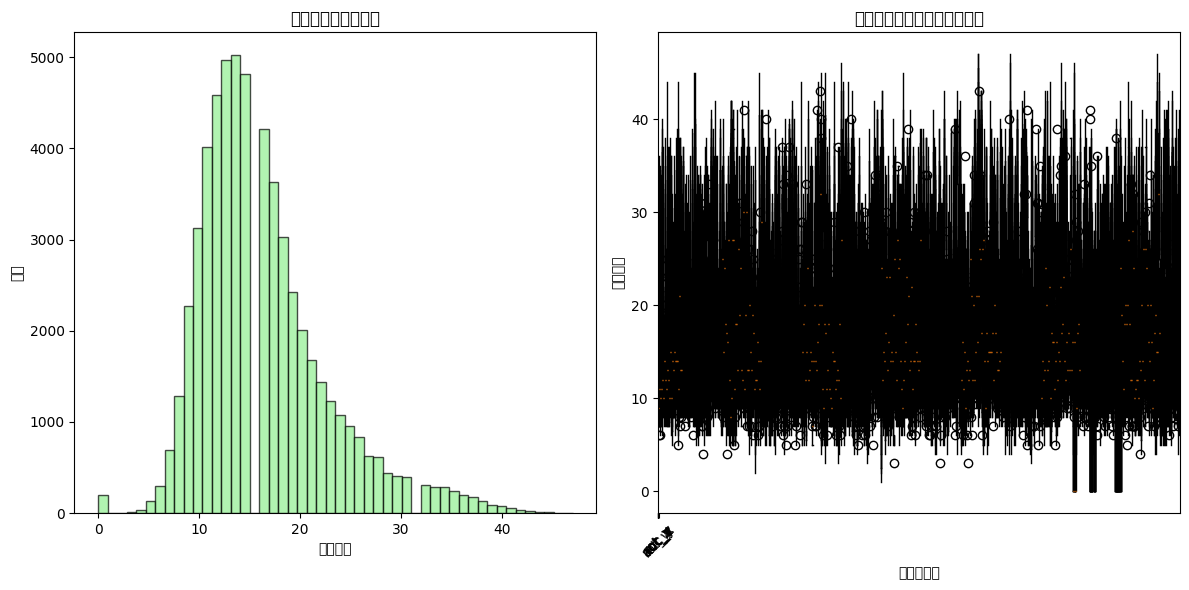


=== ジェスチャー別のピーク特徴量比較 ===
Above ear - pull hair: mean=15.1476, std=5.0193
Cheek - pinch skin: mean=15.0645, std=5.2573
Drink from bottle/cup: mean=15.7125, std=6.9220
Eyebrow - pull hair: mean=16.2975, std=6.3679
Eyelash - pull hair: mean=15.3771, std=5.2417
Feel around in tray and pull out an object: mean=20.9306, std=7.1785
Forehead - pull hairline: mean=14.9136, std=5.2174
Forehead - scratch: mean=15.1169, std=5.6210
Glasses on/off: mean=15.4750, std=7.7739
Neck - pinch skin: mean=15.2586, std=4.8169
Neck - scratch: mean=19.4533, std=8.0045
Pinch knee/leg skin: mean=14.9752, std=4.9558
Pull air toward your face: mean=13.3989, std=4.9970
Scratch knee/leg skin: mean=18.0805, std=7.5721
Text on phone: mean=18.8503, std=7.0967
Wave hello: mean=18.8072, std=6.2254
Write name in air: mean=16.3456, std=5.5782
Write name on leg: mean=15.7569, std=5.3508

ピーク特徴量を変数に保存しました。


In [ ]:
# Step 5: ピーク特徴量の計算
print("=== ピーク特徴量の計算 ===")

from src.utils.feature_engineering import compute_peak_features
# ピーク特徴量の計算
peak_features = compute_peak_features(X_sensor_normalized)
print(f"ピーク特徴量: {peak_features.shape}")
print(f"ピーク特徴量の統計: mean={peak_features.mean():.4f}, std={peak_features.std():.4f}")

# 結果の可視化
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(peak_features.flatten(), bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
plt.title('ピーク特徴量の分布')
plt.xlabel('ピーク数')
plt.ylabel('頻度')

plt.subplot(1, 2, 2)
# センサー軸別のピーク数比較
sensor_names = ['acc_x', 'acc_y', 'acc_z', 'rot_w', 'rot_x', 'rot_y', 'rot_z'] + \
              [f'thm_{i}' for i in range(1, 6)] + \
              [f'tof_{i}' for i in range(min(10, peak_features.shape[1] - 12))]
if len(sensor_names) > peak_features.shape[1]:
    sensor_names = sensor_names[:peak_features.shape[1]]

plt.boxplot(peak_features.T[:len(sensor_names)])
plt.title('センサー軸別のピーク数分布')
plt.xlabel('センサー軸')
plt.ylabel('ピーク数')
plt.xticks(range(1, len(sensor_names) + 1), sensor_names[:len(sensor_names)], rotation=45)

plt.tight_layout()
plt.show()

# 各ジェスチャーのピーク特徴量を比較
print("\n=== ジェスチャー別のピーク特徴量比較 ===")
gesture_peak_stats = {}
for gesture in unique_gestures:
    mask = y_windows == gesture
    gesture_peak_stats[gesture] = peak_features[mask].mean(axis=0)
    print(f"{gesture}: mean={peak_features[mask].mean():.4f}, std={peak_features[mask].std():.4f}")
# 例: シーケンスIDごとに全体ピーク数を計算し、ウィンドウごとに連結
seq_peak_dict = {}
for seq_id, group in df.groupby('sequence_id'):
    seq_peak_dict[seq_id] = compute_peak_features(group[sensor_cols].values[None, :, :]).flatten()

# 各ウィンドウにシーケンス全体ピーク数を付与
seq_ids = [info['sequence_id'] for info in window_info]
seq_peak_features = np.array([seq_peak_dict[seq_id] for seq_id in seq_ids])
features = np.concatenate([peak_features, seq_peak_features], axis=1)
# 結果の保存
window_data['peak_features'] = peak_features
window_data['gesture_peak_stats'] = gesture_peak_stats
print("\nピーク特徴量を変数に保存しました。")


=== FFTバンドエネルギーの計算 ===
FFTバンドエネルギー: (8343, 28)
FFTバンドエネルギーの統計: mean=660.4614, std=1049.3277


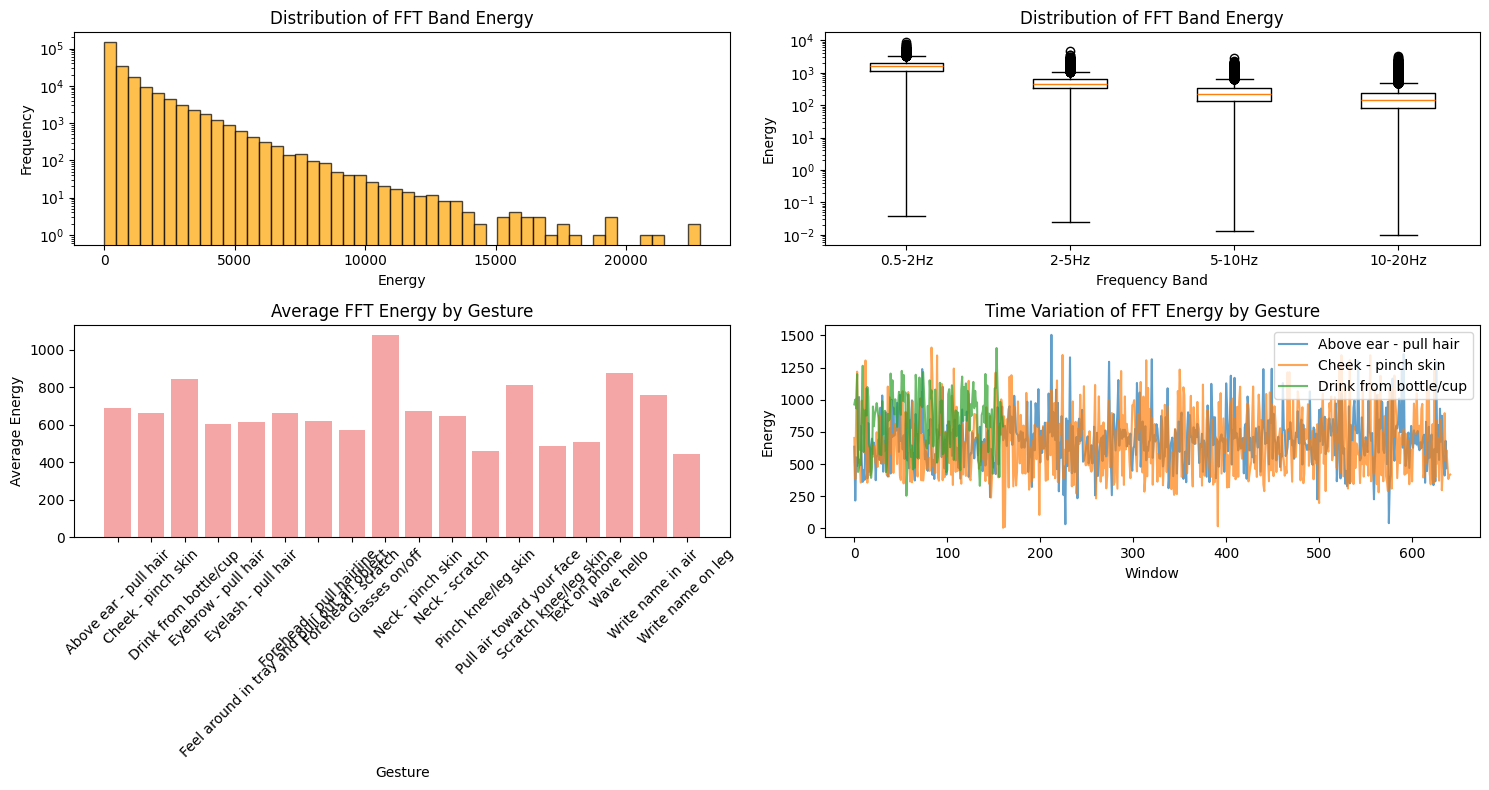


=== ジェスチャー別のFFT特徴量比較 ===
Above ear - pull hair: mean=687.8540, std=1018.8425
Cheek - pinch skin: mean=662.7133, std=1090.4969
Drink from bottle/cup: mean=845.1254, std=1034.1378
Eyebrow - pull hair: mean=602.3175, std=1019.3867
Eyelash - pull hair: mean=615.1381, std=999.1352
Feel around in tray and pull out an object: mean=661.4881, std=1235.9719
Forehead - pull hairline: mean=622.4501, std=981.6697
Forehead - scratch: mean=574.6171, std=920.8390
Glasses on/off: mean=1077.1691, std=1394.6850
Neck - pinch skin: mean=674.7545, std=1064.6615
Neck - scratch: mean=649.2138, std=1108.8812
Pinch knee/leg skin: mean=458.6485, std=764.5781
Pull air toward your face: mean=811.0273, std=1063.8315
Scratch knee/leg skin: mean=489.3959, std=877.2328
Text on phone: mean=508.9653, std=914.7166
Wave hello: mean=877.8207, std=1270.2223
Write name in air: mean=761.1520, std=1087.7690
Write name on leg: mean=446.0447, std=746.0503

FFTバンドエネルギーを変数に保存しました。


In [ ]:
# Step 6: FFTバンドエネルギーの計算
print("=== FFTバンドエネルギーの計算 ===")

from src.utils.feature_engineering import compute_fft_band_energy
# FFTバンドエネルギーの計算
fft_band_energy = compute_fft_band_energy(X_sensor_normalized, fs=50.0)
print(f"FFTバンドエネルギー: {fft_band_energy.shape}")
print(f"FFTバンドエネルギーの統計: mean={fft_band_energy.mean():.4f}, std={fft_band_energy.std():.4f}")

# 結果の可視化
plt.figure(figsize=(15, 8))

# 全体の分布
plt.subplot(2, 2, 1)
plt.hist(fft_band_energy.flatten(), bins=50, alpha=0.7, color='orange', edgecolor='black')
plt.title('Distribution of FFT Band Energy')
plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.yscale('log')

# 周波数バンド別の分布
plt.subplot(2, 2, 2)
band_names = ['0.5-2Hz', '2-5Hz', '5-10Hz', '10-20Hz']
n_bands = len(band_names)
n_sensors = fft_band_energy.shape[1] // n_bands
band_data = []
for i in range(n_bands):
    band_data.append(fft_band_energy[:, i*n_sensors:(i+1)*n_sensors].mean(axis=1))

plt.boxplot(band_data)
plt.title('Distribution of FFT Band Energy')
plt.xlabel('Frequency Band')
plt.ylabel('Energy')
plt.xticks(range(1, len(band_names) + 1), band_names)
plt.yscale('log')

# ジェスチャー別の比較
plt.subplot(2, 2, 3)
gesture_fft_means = []
for gesture in unique_gestures:
    mask = y_windows == gesture
    gesture_fft_means.append(fft_band_energy[mask].mean())

plt.bar(range(len(unique_gestures)), gesture_fft_means, alpha=0.7, color='lightcoral')
plt.title('Average FFT Energy by Gesture')
plt.xlabel('Gesture')
plt.ylabel('Average Energy')
plt.xticks(range(len(unique_gestures)), [str(g) for g in unique_gestures], rotation=45)

# 時間経過による変化
plt.subplot(2, 2, 4)
for i, gesture in enumerate(unique_gestures[:3]):  # 最初の3つのジェスチャーのみ
    mask = y_windows == gesture
    gesture_data = fft_band_energy[mask]
    if len(gesture_data) > 0:
        plt.plot(gesture_data.mean(axis=1), label=gesture, alpha=0.7)

plt.title('Time Variation of FFT Energy by Gesture')
plt.xlabel('Window')
plt.ylabel('Energy')
plt.legend()

plt.tight_layout()
plt.show()

# 各ジェスチャーのFFT特徴量を比較
print("\n=== ジェスチャー別のFFT特徴量比較 ===")
gesture_fft_stats = {}
for gesture in unique_gestures:
    mask = y_windows == gesture
    gesture_fft_stats[gesture] = fft_band_energy[mask].mean(axis=0)
    print(f"{gesture}: mean={fft_band_energy[mask].mean():.4f}, std={fft_band_energy[mask].std():.4f}")

# 結果の保存
window_data['fft_band_energy'] = fft_band_energy
window_data['gesture_fft_stats'] = gesture_fft_stats
print("\nFFTバンドエネルギーを変数に保存しました。")


=== Wavelet特徴量の計算 ===
Wavelet特徴量: (8343, 28)
Wavelet特徴量の統計: mean=47.3312, std=101.8069


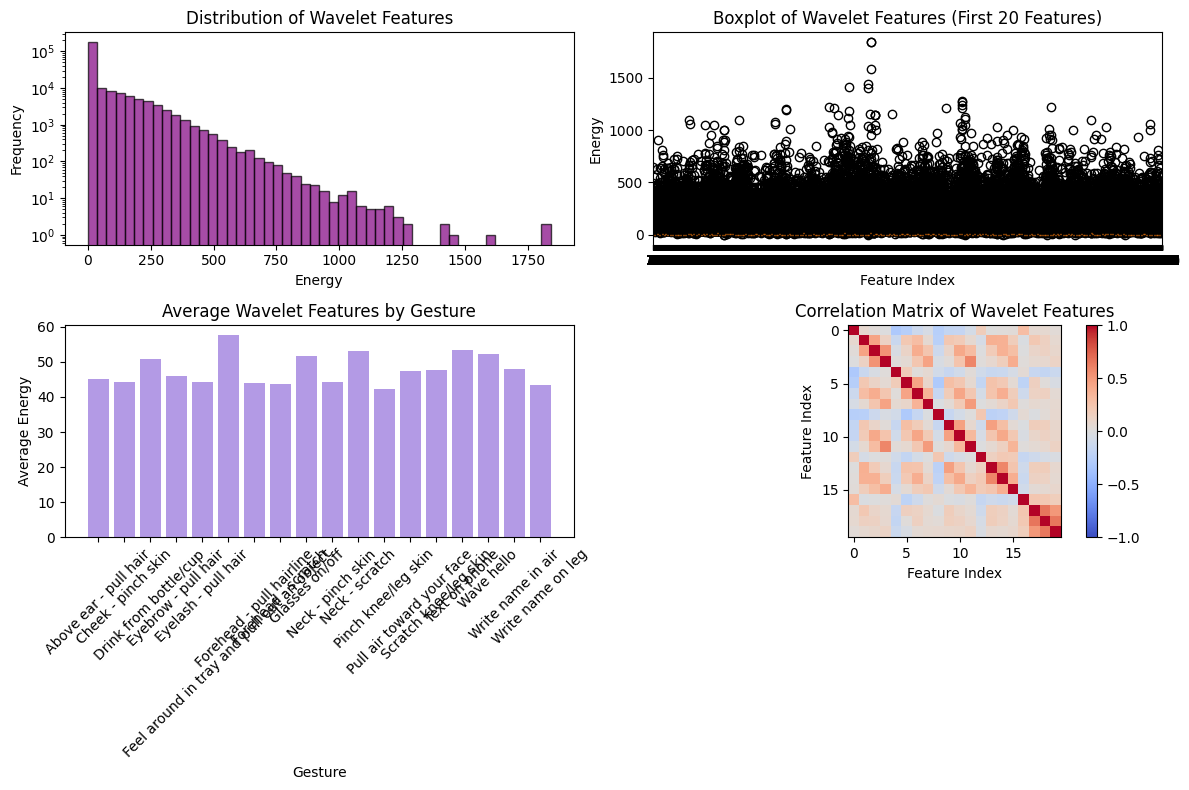


=== ジェスチャー別のWavelet特徴量比較 ===
Above ear - pull hair: mean=45.0749, std=93.2063
Cheek - pinch skin: mean=44.1302, std=94.3288
Drink from bottle/cup: mean=50.6797, std=97.3376
Eyebrow - pull hair: mean=46.0309, std=101.3222
Eyelash - pull hair: mean=44.1861, std=94.2957
Feel around in tray and pull out an object: mean=57.5533, std=126.4378
Forehead - pull hairline: mean=44.0025, std=93.6323
Forehead - scratch: mean=43.8168, std=95.4637
Glasses on/off: mean=51.7778, std=98.0956
Neck - pinch skin: mean=44.3380, std=93.5016
Neck - scratch: mean=53.0939, std=124.2359
Pinch knee/leg skin: mean=42.3836, std=89.5111
Pull air toward your face: mean=47.2666, std=93.1468
Scratch knee/leg skin: mean=47.7713, std=104.4560
Text on phone: mean=53.3130, std=121.0430
Wave hello: mean=52.2685, std=102.7051
Write name in air: mean=48.0511, std=99.0895
Write name on leg: mean=43.2754, std=91.5893

Wavelet特徴量を変数に保存しました。


In [ ]:
# Step 7: Wavelet特徴量の計算
print("=== Wavelet特徴量の計算 ===")

from src.utils.feature_engineering import compute_wavelet_features
# Wavelet特徴量の計算（PyWaveletsが必要）
try:
    import pywt
    wavelet_features = compute_wavelet_features(X_sensor_normalized, wavelet="db4", level=3)
    print(f"Wavelet特徴量: {wavelet_features.shape}")
    print(f"Wavelet特徴量の統計: mean={wavelet_features.mean():.4f}, std={wavelet_features.std():.4f}")
    
    # 結果の可視化
    plt.figure(figsize=(12, 8))
    
    # 全体の分布
    plt.subplot(2, 2, 1)
    plt.hist(wavelet_features.flatten(), bins=50, alpha=0.7, color='purple', edgecolor='black')
    plt.title('Distribution of Wavelet Features')
    plt.xlabel('Energy')
    plt.ylabel('Frequency')
    plt.yscale('log')
    
    # 箱ひげ図
    plt.subplot(2, 2, 2)
    plt.boxplot(wavelet_features.T[:20])  # 最初の20個の特徴量のみ表示
    plt.title('Boxplot of Wavelet Features (First 20 Features)')
    plt.xlabel('Feature Index')
    plt.ylabel('Energy')
    
    # ジェスチャー別の比較
    plt.subplot(2, 2, 3)
    gesture_wavelet_means = []
    for gesture in unique_gestures:
        mask = y_windows == gesture
        gesture_wavelet_means.append(wavelet_features[mask].mean())
    
    plt.bar(range(len(unique_gestures)), gesture_wavelet_means, alpha=0.7, color='mediumpurple')
    plt.title('Average Wavelet Features by Gesture')
    plt.xlabel('Gesture')
    plt.ylabel('Average Energy')
    plt.xticks(range(len(unique_gestures)), [str(g) for g in unique_gestures], rotation=45)
    
    # 相関行列
    plt.subplot(2, 2, 4)
    corr_matrix = np.corrcoef(wavelet_features.T[:20])  # 最初の20個の特徴量のみ
    plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar()
    plt.title('Correlation Matrix of Wavelet Features')
    plt.xlabel('Feature Index')
    plt.ylabel('Feature Index')
    
    plt.tight_layout()
    plt.show()
    
    # 各ジェスチャーのWavelet特徴量を比較
    print("\n=== ジェスチャー別のWavelet特徴量比較 ===")
    gesture_wavelet_stats = {}
    for gesture in unique_gestures:
        mask = y_windows == gesture
        gesture_wavelet_stats[gesture] = wavelet_features[mask].mean(axis=0)
        print(f"{gesture}: mean={wavelet_features[mask].mean():.4f}, std={wavelet_features[mask].std():.4f}")
    
    # 結果の保存
    window_data['wavelet_features'] = wavelet_features
    window_data['gesture_wavelet_stats'] = gesture_wavelet_stats
    print("\nWavelet特徴量を変数に保存しました。")
    
except ImportError:
    print("PyWaveletsがインストールされていません。pip install PyWaveletsでインストールしてください。")
    wavelet_features = None
    gesture_wavelet_stats = None
    print("Wavelet特徴量の計算をスキップしました。")


=== AutoEncoder再構成誤差の計算 ===
X_sensor_normalized shape: (8343, 128, 7)
AutoEncoderの訓練中...
Epoch 1/50


2025-07-11 21:31:51.663508: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_336_0', 4 bytes spill stores, 4 bytes spill loads

2025-07-11 21:31:52.638643: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_336', 292 bytes spill stores, 292 bytes spill loads



402/418 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5342

2025-07-11 21:31:57.536145: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_336', 24 bytes spill stores, 24 bytes spill loads



418/418 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.5279 - val_loss: 0.2519
Epoch 2/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2393 - val_loss: 0.2187
Epoch 3/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2109 - val_loss: 0.2014
Epoch 4/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1957 - val_loss: 0.1926
Epoch 5/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1868 - val_loss: 0.1863
Epoch 6/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1786 - val_loss: 0.1779
Epoch 7/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1704 - val_loss: 0.1764
Epoch 8/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1683 - val_loss: 0.1743
Epoch 9/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1642 - val_loss: 0.1691
Epoch 10/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1597 - val_loss: 0.1688
Epoch 11/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1589 - val_loss: 0.1705
Epoch 12/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 

2025-07-11 21:33:16.965367: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32', 12 bytes spill stores, 12 bytes spill loads



AutoEncoder再構成誤差: (8343, 1)
再構成誤差の統計: mean=0.136887, std=0.106166


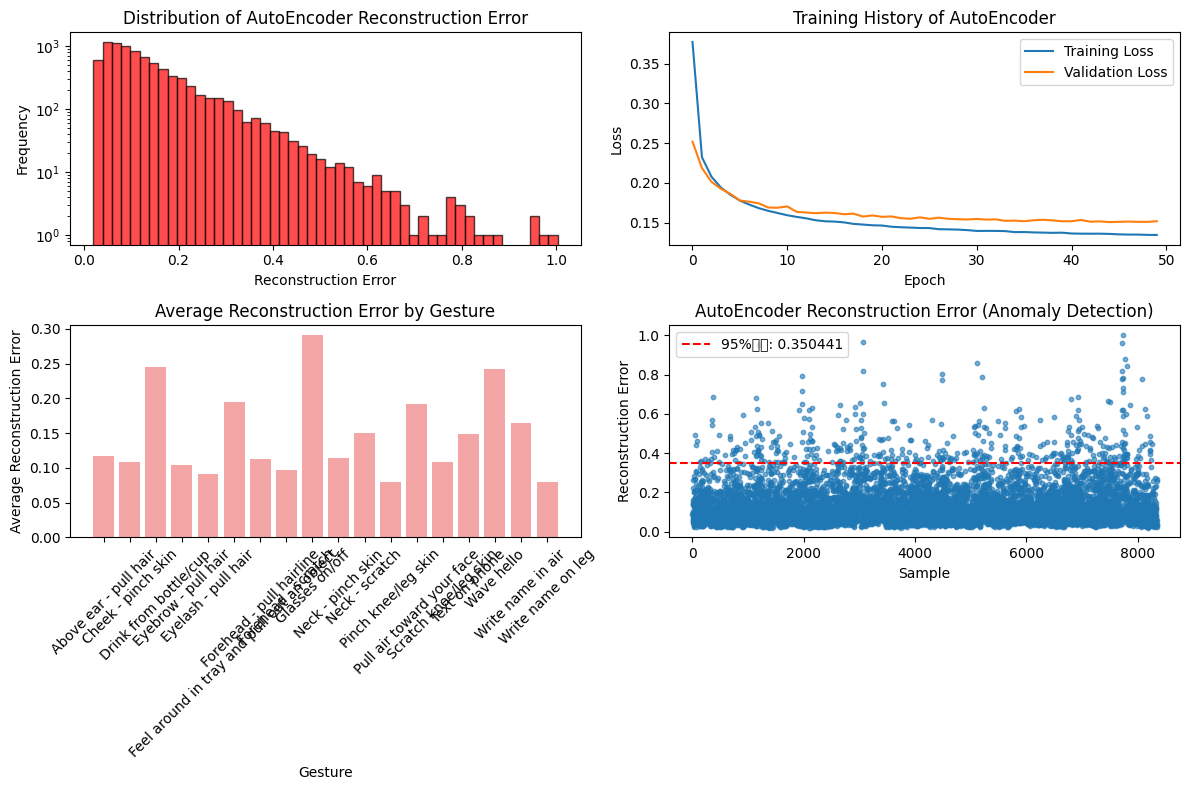


=== ジェスチャー別のAutoEncoder再構成誤差比較 ===
Above ear - pull hair: mean=0.116433, std=0.074267
Cheek - pinch skin: mean=0.108497, std=0.074523
Drink from bottle/cup: mean=0.244730, std=0.094967
Eyebrow - pull hair: mean=0.103876, std=0.087686
Eyelash - pull hair: mean=0.090846, std=0.063615
Feel around in tray and pull out an object: mean=0.195398, std=0.130521
Forehead - pull hairline: mean=0.112166, std=0.079898
Forehead - scratch: mean=0.097634, std=0.067467
Glasses on/off: mean=0.290708, std=0.128484
Neck - pinch skin: mean=0.113561, std=0.080043
Neck - scratch: mean=0.150699, std=0.117914
Pinch knee/leg skin: mean=0.079332, std=0.060644
Pull air toward your face: mean=0.191684, std=0.106183
Scratch knee/leg skin: mean=0.108761, std=0.098264
Text on phone: mean=0.148864, std=0.118916
Wave hello: mean=0.242503, std=0.141414
Write name in air: mean=0.163947, std=0.090350
Write name on leg: mean=0.080160, std=0.057206

AutoEncoder再構成誤差を変数に保存しました。


In [ ]:
# Step 8: AutoEncoder再構成誤差の計算
print("=== AutoEncoder再構成誤差の計算 ===")

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Input, Flatten, Reshape
    
    # データ形状の確認と修正
    print(f"X_sensor_normalized shape: {X_sensor_normalized.shape}")
    
    # データをFlattenしてAutoEncoder用に準備
    n_samples, window_size, n_features = X_sensor_normalized.shape
    X_flat = X_sensor_normalized.reshape(n_samples, -1)  # (n_samples, window_size * n_features)
    
    # AutoEncoderモデルの作成（Flattenされたデータ用）
    input_dim = X_flat.shape[1]
    encoding_dim = min(32, input_dim // 4)  # エンコーディング次元を適切に設定
    
    autoencoder = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dense(encoding_dim, activation='relu'),  # エンコーダー
        Dense(128, activation='relu'),
        Dense(input_dim, activation='linear')    # デコーダー
    ])
    
    autoencoder.compile(optimizer='adam', loss='mse')
    
    # より詳細な学習設定
    print("AutoEncoderの訓練中...")
    history = autoencoder.fit(
        X_flat, X_flat,
        epochs=50,  # エポック数を増やす
        batch_size=16,  # バッチサイズを小さく
        verbose=1,  # 詳細ログを表示
        validation_split=0.2,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=5,
                restore_best_weights=True
            )
        ]
    )
    
    # 再構成誤差の計算（Flattenされたデータ用）
    recon = autoencoder.predict(X_flat, verbose=0)
    ae_errors = ((X_flat - recon) ** 2).mean(axis=1, keepdims=True)
    
    print(f"AutoEncoder再構成誤差: {ae_errors.shape}")
    print(f"再構成誤差の統計: mean={ae_errors.mean():.6f}, std={ae_errors.std():.6f}")
    
    # 結果の可視化
    plt.figure(figsize=(12, 8))
    
    # 全体の分布
    plt.subplot(2, 2, 1)
    plt.hist(ae_errors.flatten(), bins=50, alpha=0.7, color='red', edgecolor='black')
    plt.title('Distribution of AutoEncoder Reconstruction Error')
    plt.xlabel('Reconstruction Error')
    plt.ylabel('Frequency')
    plt.yscale('log')
    
    # 訓練履歴
    plt.subplot(2, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training History of AutoEncoder')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # ジェスチャー別の比較
    plt.subplot(2, 2, 3)
    gesture_ae_means = []
    for gesture in unique_gestures:
        mask = y_windows == gesture
        gesture_ae_means.append(ae_errors[mask].mean())
    
    plt.bar(range(len(unique_gestures)), gesture_ae_means, alpha=0.7, color='lightcoral')
    plt.title('Average Reconstruction Error by Gesture')
    plt.xlabel('Gesture')
    plt.ylabel('Average Reconstruction Error')
    plt.xticks(range(len(unique_gestures)), [str(g) for g in unique_gestures], rotation=45)
    
    # 異常検出のしきい値
    plt.subplot(2, 2, 4)
    threshold = np.percentile(ae_errors, 95)
    plt.scatter(range(len(ae_errors)), ae_errors.flatten(), alpha=0.6, s=10)
    plt.axhline(y=threshold, color='red', linestyle='--', label=f'95%閾値: {threshold:.6f}')
    plt.title('AutoEncoder Reconstruction Error (Anomaly Detection)')
    plt.xlabel('Sample')
    plt.ylabel('Reconstruction Error')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 各ジェスチャーのAutoEncoder特徴量を比較
    print("\n=== ジェスチャー別のAutoEncoder再構成誤差比較 ===")
    gesture_ae_stats = {}
    for gesture in unique_gestures:
        mask = y_windows == gesture
        gesture_ae_stats[gesture] = ae_errors[mask].mean()
        print(f"{gesture}: mean={ae_errors[mask].mean():.6f}, std={ae_errors[mask].std():.6f}")
    
    # 結果の保存
    window_data['ae_errors'] = ae_errors
    window_data['gesture_ae_stats'] = gesture_ae_stats
    window_data['autoencoder_model'] = autoencoder
    print("\nAutoEncoder再構成誤差を変数に保存しました。")
    
except ImportError:
    print("TensorFlow/Kerasがインストールされていません。pip install tensorflowでインストールしてください。")
    ae_errors = None
    gesture_ae_stats = None
    print("AutoEncoder再構成誤差の計算をスキップしました。")
except Exception as e:
    print(f"AutoEncoder計算中にエラーが発生しました: {e}")
    ae_errors = None
    gesture_ae_stats = None
    print("AutoEncoder再構成誤差の計算をスキップしました。")


## Step 9: TDA特徴量の計算


In [ ]:
print("=== TDA特徴量（パーシステンス画像）の計算 ===")
from src.utils.feature_engineering import compute_persistence_image_features_batch

# 既存の関数をバッチ処理用に修正
def compute_persistence_image_features_batch(X_windows: np.ndarray, dimension:int=2, n_bins:int=16, sigma:float=0.1) -> np.ndarray:
    from gtda.time_series import TakensEmbedding
    from gtda.homology import VietorisRipsPersistence
    from gtda.diagrams import PersistenceImage

    # 1. Takens埋め込み（全ウィンドウまとめて）
    emb = TakensEmbedding(time_delay=1, dimension=dimension)
    embedded = emb.fit_transform(X_windows)  # shape: (n_samples, new_len, dimension)

    # 2. パーシステンス図（全ウィンドウまとめて）
    vrp = VietorisRipsPersistence(homology_dimensions=[0, 1])
    diagrams = vrp.fit_transform(embedded)   # shape: (n_samples, n_points, 3)

    # 3. パーシステンス画像（全ウィンドウまとめて）
    pim = PersistenceImage(sigma=sigma, n_bins=n_bins)
    images = pim.fit_transform(diagrams)     # shape: (n_samples, n_bins, n_bins)

    # 4. ベクトル化
    feats = images.reshape(images.shape[0], -1)
    return feats.astype(np.float32)

# 実行例
tda_features = compute_persistence_image_features_batch(
    X_sensor_normalized, dimension=2, n_bins=16, sigma=0.1
)
print(f"TDA特徴量: {tda_features.shape}")
print(f"平均: {tda_features.mean()}, 標準偏差: {tda_features.std()}")
# all_features.append(tda_features)
# feature_names.append('TDA特徴量')

window_data['tda_features'] = tda_features
# window_data['gesture_peak_stats'] = gesture_peak_stats


=== TDA特徴量（パーシステンス画像）の計算 ===
TDA特徴量: (8343, 512)
平均: 0.0019828525837510824, 標準偏差: 0.029090523719787598


## Step 9-2: TDA特徴量の可視化


=== TDA特徴量（パーシステンス画像）の可視化 ===


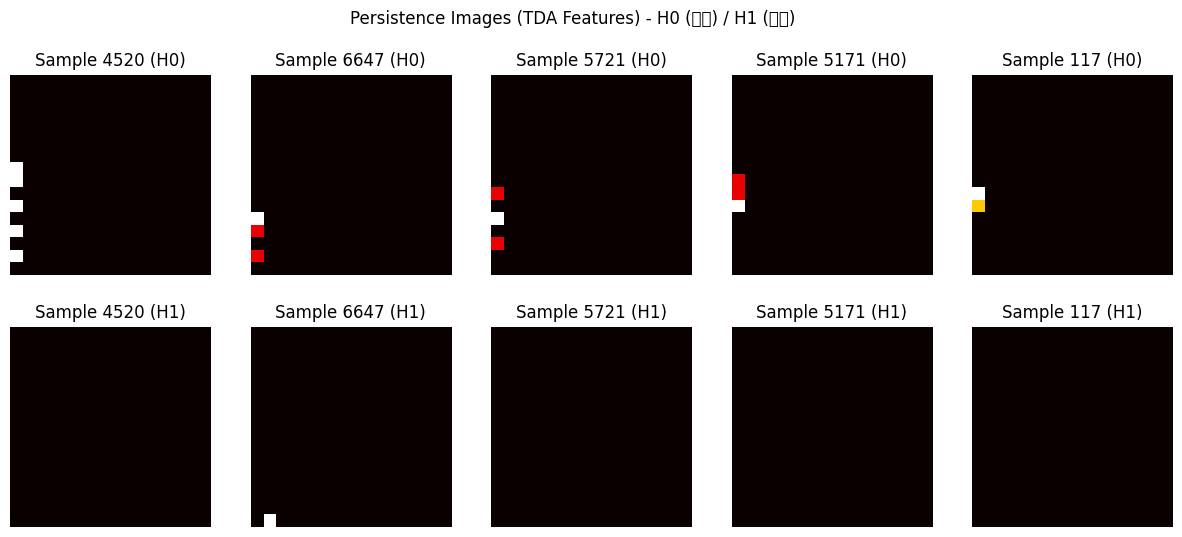

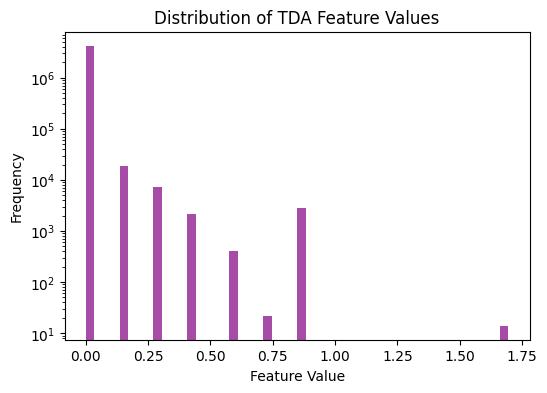

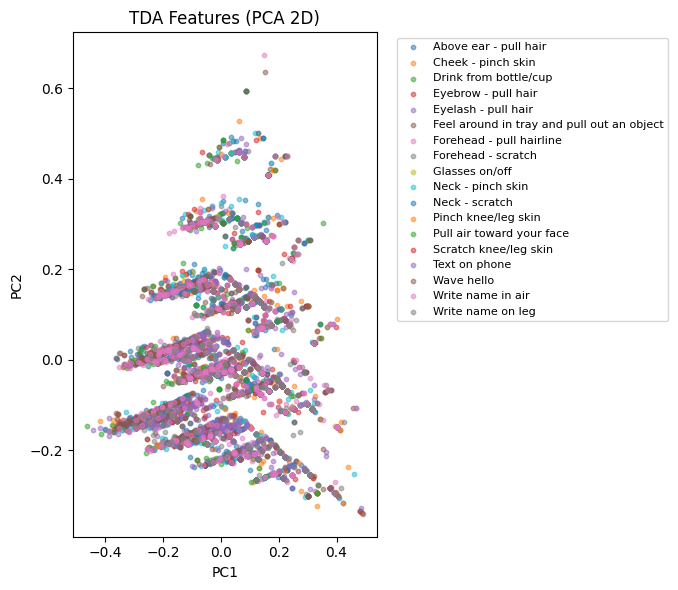

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("=== TDA特徴量（パーシステンス画像）の可視化 ===")

tda_features = window_data['tda_features']  # (サンプル数, 512)
n_bins = 16  # n_binsを明示的に指定

# 1. ランダムなサンプルのパーシステンス画像（次数0,1両方）を表示
num_samples = 5
sample_indices = np.random.choice(tda_features.shape[0], num_samples, replace=False)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(sample_indices):
    img0 = tda_features[idx][:n_bins*n_bins].reshape(n_bins, n_bins)      # 次数0
    img1 = tda_features[idx][n_bins*n_bins:].reshape(n_bins, n_bins)      # 次数1
    plt.subplot(2, num_samples, i+1)
    plt.imshow(img0, cmap='hot', interpolation='nearest')
    plt.title(f'Sample {idx} (H0)')
    plt.axis('off')
    plt.subplot(2, num_samples, i+1+num_samples)
    plt.imshow(img1, cmap='hot', interpolation='nearest')
    plt.title(f'Sample {idx} (H1)')
    plt.axis('off')
plt.suptitle('Persistence Images (TDA Features) - H0 (上段) / H1 (下段)')
plt.show()

# 2. TDA特徴量の分布（全体ヒストグラム）
plt.figure(figsize=(6, 4))
plt.hist(tda_features.flatten(), bins=50, color='purple', alpha=0.7)
plt.title('Distribution of TDA Feature Values')
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

# 3. PCAで2次元に圧縮して可視化
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
tda_pca = pca.fit_transform(tda_features)

plt.figure(figsize=(7, 6))
for gesture in np.unique(y_windows):
    mask = (y_windows == gesture)
    plt.scatter(tda_pca[mask, 0], tda_pca[mask, 1], label=gesture, alpha=0.5, s=10)
plt.title('TDA Features (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# Step 10: 特徴量の統合・可視化


=== 特徴量の統合・可視化 ===
ピーク特徴量: (8343, 7)
FFTバンドエネルギー: (8343, 28)
Wavelet特徴量: (8343, 28)
AutoEncoder再構成誤差: (8343, 1)
人口統計データ: (8343, 7)
TDA特徴量: (8343, 512)

統合された特徴量: (8343, 583)
正規化後の特徴量: (8343, 583)


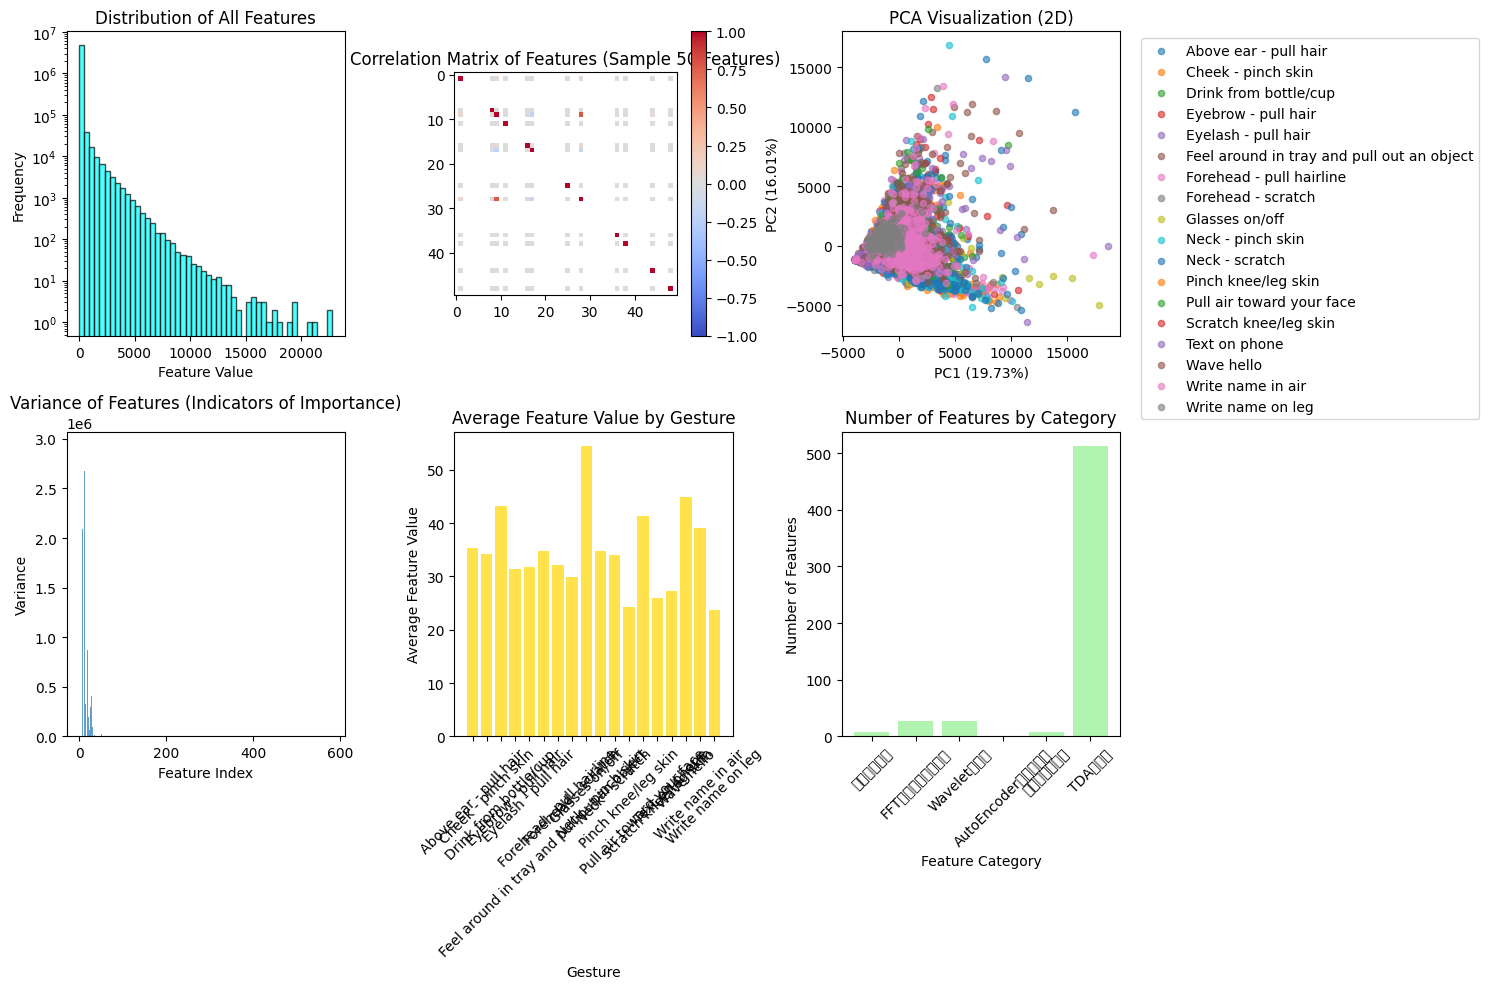


特徴量統合完了:
  総特徴量数: 583
  総サンプル数: 8343
  特徴量カテゴリ数: 6


In [ ]:
print("=== 特徴量の統合・可視化 ===")

# 利用可能な特徴量を統合
all_features = []
feature_names = []

# 基本統計量
if 'basic_stats' in window_data and window_data['basic_stats'] is not None:
    all_features.append(window_data['basic_stats'])
    feature_names.append('基本統計量')
    print(f"基本統計量: {window_data['basic_stats'].shape}")

# ピーク特徴量
if 'peak_features' in window_data and window_data['peak_features'] is not None:
    all_features.append(window_data['peak_features'])
    feature_names.append('ピーク特徴量')
    print(f"ピーク特徴量: {window_data['peak_features'].shape}")

# FFTバンドエネルギー
if 'fft_band_energy' in window_data and window_data['fft_band_energy'] is not None:
    all_features.append(window_data['fft_band_energy'])
    feature_names.append('FFTバンドエネルギー')
    print(f"FFTバンドエネルギー: {window_data['fft_band_energy'].shape}")

# Wavelet特徴量
if 'wavelet_features' in window_data and window_data['wavelet_features'] is not None:
    all_features.append(window_data['wavelet_features'])
    feature_names.append('Wavelet特徴量')
    print(f"Wavelet特徴量: {window_data['wavelet_features'].shape}")

# AutoEncoder再構成誤差
if 'ae_errors' in window_data and window_data['ae_errors'] is not None:
    all_features.append(window_data['ae_errors'])
    feature_names.append('AutoEncoder再構成誤差')
    print(f"AutoEncoder再構成誤差: {window_data['ae_errors'].shape}")

# 人口統計データ
if 'X_demographics_normalized' in window_data and window_data['X_demographics_normalized'] is not None:
    all_features.append(window_data['X_demographics_normalized'])
    feature_names.append('人口統計データ')
    print(f"人口統計データ: {window_data['X_demographics_normalized'].shape}")

# TDA特徴量
if 'tda_features' in window_data and window_data['tda_features'] is not None:
    all_features.append(window_data['tda_features'])
    feature_names.append('TDA特徴量')
    print(f"TDA特徴量: {window_data['tda_features'].shape}")

# 特徴量の統合
if all_features:
    combined_features = np.concatenate(all_features, axis=1)
    print(f"\n統合された特徴量: {combined_features.shape}")
    # ★ここで正規化（z-score標準化）を追加
    combined_features_normalized, combined_scaler = normalize_tabular_data(combined_features)
    print(f"正規化後の特徴量: {combined_features_normalized.shape}")

    # 可視化やモデル学習には正規化後のデータを使う
    window_data['combined_features'] = combined_features_normalized
    window_data['feature_names'] = feature_names
    window_data['combined_scaler'] = combined_scaler
    # 特徴量の可視化
    plt.figure(figsize=(15, 10))
    
    # 特徴量の分布
    plt.subplot(2, 3, 1)
    plt.hist(combined_features.flatten(), bins=50, alpha=0.7, color='cyan', edgecolor='black')
    plt.title('Distribution of All Features')
    plt.xlabel('Feature Value')
    plt.ylabel('Frequency')
    plt.yscale('log')
    
    # 特徴量間の相関
    plt.subplot(2, 3, 2)
    # サンプリングして相関を計算（計算量軽減のため）
    sample_size = min(50, combined_features.shape[1])
    sample_indices = np.random.choice(combined_features.shape[1], sample_size, replace=False)
    corr_matrix = np.corrcoef(combined_features[:, sample_indices].T)
    plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar()
    plt.title(f'Correlation Matrix of Features (Sample {sample_size} Features)')
    
    # PCA分析
    plt.subplot(2, 3, 3)
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    features_pca = pca.fit_transform(combined_features)
    
    for i, gesture in enumerate(unique_gestures):
        mask = y_windows == gesture
        plt.scatter(features_pca[mask, 0], features_pca[mask, 1], 
                   alpha=0.6, label=gesture, s=20)
    
    plt.title('PCA Visualization (2D)')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 特徴量の重要度（分散ベース）
    plt.subplot(2, 3, 4)
    feature_variance = np.var(combined_features, axis=0)
    plt.bar(range(len(feature_variance)), feature_variance, alpha=0.7)
    plt.title('Variance of Features (Indicators of Importance)')
    plt.xlabel('Feature Index')
    plt.ylabel('Variance')
    
    # ジェスチャー別の特徴量平均
    plt.subplot(2, 3, 5)
    gesture_means = []
    for gesture in unique_gestures:
        mask = y_windows == gesture
        gesture_means.append(combined_features[mask].mean())
    
    plt.bar(range(len(unique_gestures)), gesture_means, alpha=0.7, color='gold')
    plt.title('Average Feature Value by Gesture')
    plt.xlabel('Gesture')
    plt.ylabel('Average Feature Value')
    plt.xticks(range(len(unique_gestures)), [str(g) for g in unique_gestures], rotation=45)
    
    # 特徴量の次元数比較
    plt.subplot(2, 3, 6)
    feature_dims = [feat.shape[1] for feat in all_features]
    plt.bar(range(len(feature_names)), feature_dims, alpha=0.7, color='lightgreen')
    plt.title('Number of Features by Category')
    plt.xlabel('Feature Category')
    plt.ylabel('Number of Features')
    plt.xticks(range(len(feature_names)), feature_names, rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # 結果の保存
    window_data['combined_features'] = combined_features
    window_data['feature_names'] = feature_names
    window_data['pca_features'] = features_pca
    window_data['pca_model'] = pca
    
    print(f"\n特徴量統合完了:")
    print(f"  総特徴量数: {combined_features.shape[1]}")
    print(f"  総サンプル数: {combined_features.shape[0]}")
    print(f"  特徴量カテゴリ数: {len(feature_names)}")
    
else:
    print("利用可能な特徴量がありません。前のセルを実行してください。")
